### Данные

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt

import pickle
filename = 'monthly_data.pkl'
with open(filename, 'rb') as f:
    monthly_data = pickle.load(f)
sd_df = pd.read_excel('data/pi_e/s_d.xlsx')

from structuralvar import Clean, SVAR_KL
var_spec_pie = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 2, 1)),
                                   ['pi_e', 'pi_e_wos', 'pi_e_ws', 'cons', 'wage']])
var_spec = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 2, 1)),
                                   ['ru_cpi', 'real_ruonia', 'ipi', 'log_deposits_hh', 'log_credits_hh',
                                     'real_brent', 'pi_e', 'pi_e_ws', 'pi_e_wos', 'real_dollar', 'govspend']])

df, data = var_spec.LOS(use_harmonics=False, only_KPSS = True, hp_filter_map={
                                                                               'ru_cpi': True,
                                                                               'real_rate': False,
                                                                               'm2x_sa_mom': True})
df_pie, data_pie = var_spec_pie.LOS(use_harmonics=False, only_KPSS = True)

covid_start, duration_covid = (data.T.index < dt(2020, 3, 1)).sum(), 5
svo_start, svo_duration = (data.T.index < dt(2022, 2, 1)).sum(), 2

### Исследование

#### Решение проблем с отсутствием данных за ковидный период

Отсутствуют данные за Апрель, Май, Июнь, Июль 2020 года

Построем данные с помощью прогноза и внешних данных (индексе оптимизма и объем фонда зарплаты в России)

In [ ]:
lag = 2

endog_names_pie_general = ['wage', 'cons']
endog_names_pie_special = ['pi_e', 'pi_e_ws', 'pi_e_wos']
results = {}
for var in endog_names_pie_special:
    df_endog = data_pie.loc[endog_names_pie_general + [var], :].copy()
    df_endog = df_endog.loc[:,df_endog.columns < dt(2020, 4, 1)].copy()   # K×T

    model = SVAR_KL(
        data=df_endog,
        p=lag,
        layout="KL_KxT",
        time_order="chronological",
        add_const=True,
        u_dict = ['шок доходов', 'шок оптимизма', 'шок ОИ'],
        y_dict = ['Объем фонда зарплаты (логарифм)', 'индекс оптимизма', 'инфляционные ожидания']
    ).fit_ols()
    A_hat = model.A_hat
    p = model.p
    K = model.K
    
    unknown_mask = np.array([False, False, True])  

    known_future = data_pie.loc[endog_names_pie_general, :].copy().loc[:,
                        (data_pie.columns > dt(2020, 3, 1)) & (data_pie.columns < dt(2020, 8, 1))]
    res = []
    horizon = known_future.shape[1]
    counter = 0
    future = pd.DataFrame(columns=known_future.columns)
    for i, b in enumerate(unknown_mask):
        
        if not b:
            future.loc[known_future.index.to_list()[i-counter]] = known_future.iloc[i-counter]
        else:
            counter += 1
            future.loc[var] = np.zeros(horizon)    
    for h in range(horizon):
        if h == 0:
            X = model.Z[:, -1]
            
        else:
            
            X = np.hstack([np.array([1]), future.iloc[:, h-1].to_numpy(), X[1:-(K)]])
        y_hat = (A_hat @ X)[unknown_mask]
        future.loc[unknown_mask, future.columns[h]] = y_hat.item()
    results[var] = future.loc[unknown_mask, :]

for var in results:
    data.loc[var,(data.columns > dt(2020, 3, 1)) & (data.columns < dt(2020, 8, 1))] = results[var].to_numpy()

#### Основная модель

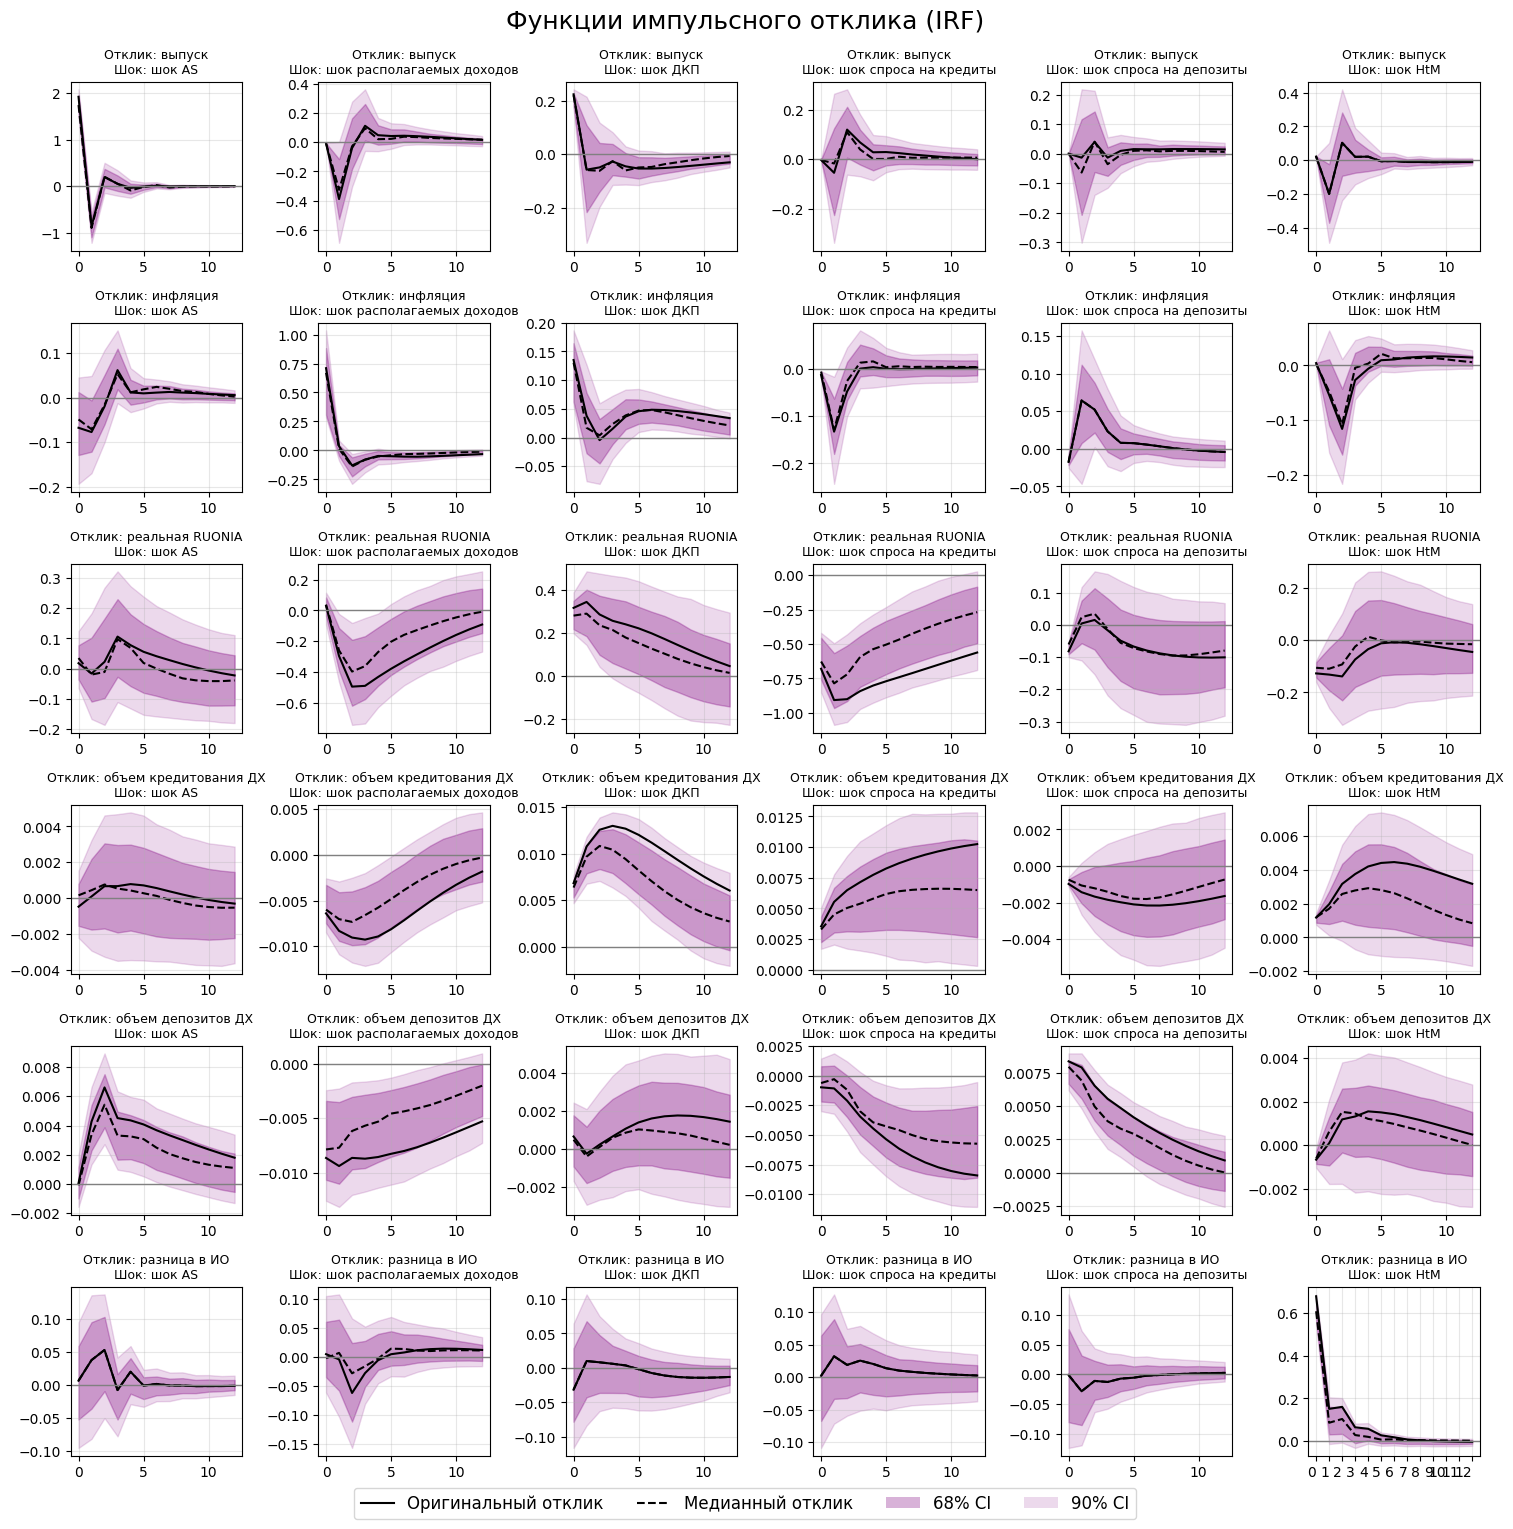

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


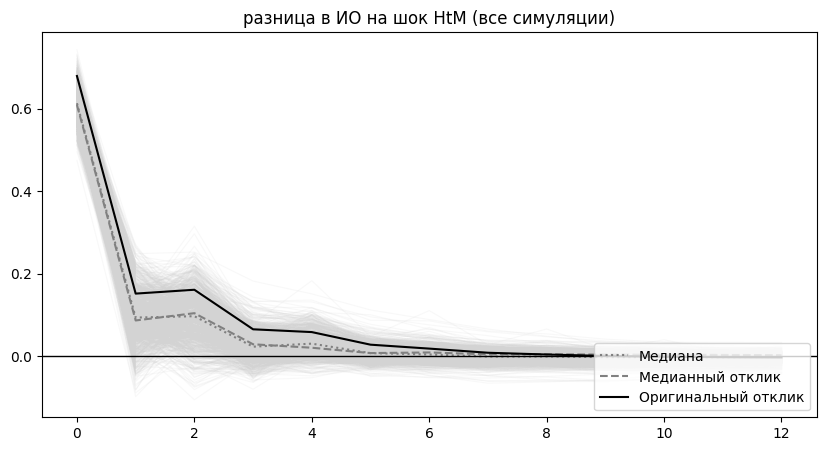

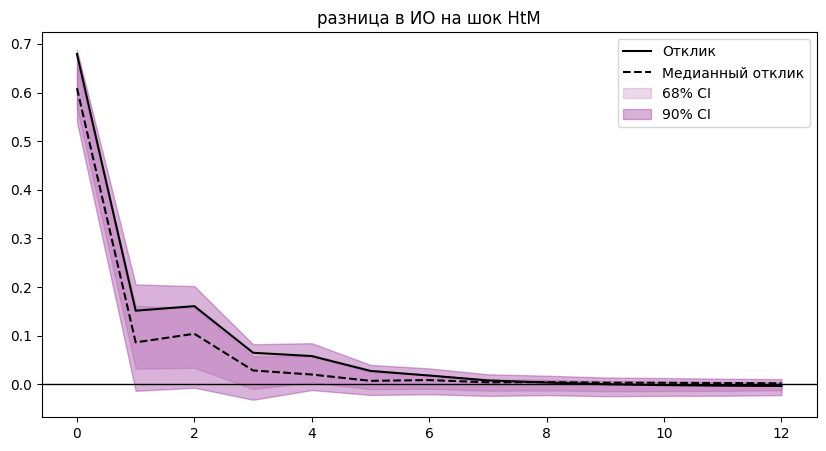

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
data.loc['pi_e_hete'] = data.loc['pi_e_wos'] - data.loc['pi_e_ws']

short_run_anchor = [
    (0, 0, 1, 0, 1),
]
long_run_anchor = [
    (0, 2, 2, 10)
]
short_run_signs = [#(0, 1, 2, False, 0, 2),
                   (0, 1, 1, True, 0, 1),
                   (0, 2, 2, True, 0, 1),
                   (0, 3, 3, True, 0, 1),
                   (0, 0, 0, True, 0, 1),
                   (0, 5, 5, True, 0, 1),
                   (0, 4, 4, True, 0, 1),
                   #(0, 3, 2, False, 0, 1),
                   #(0, 4, 3, True, 0, 1),
                   #(0, 1, 4, False, 0, 1),
                   #(0, 1, 4, False, 0, 1),
                   #(0, 5, 2, False, 0, 1),
                   #(1, 5, 5, True, 0, 10),
                   #(0, 5, 4, False, 0, 10),
                   #(0, 5, 3, True, 0, 10)
                   ]
long_run_signs = [
    #(0, 2, 1, True,  3),
    #(0, 3, 2, False, 3),
    #(0, 5, 3, True, 3)
]
lag = 2

endog_names = ['ipi', 'ru_cpi', 'real_ruonia', 'log_credits_hh', 'log_deposits_hh', 'pi_e_hete']
exog_names  = ['real_brent']

df_endog = data.loc[endog_names, :]   # K×T
df_exog  = data.loc[exog_names, :]    # K_ex×T

model = SVAR_KL(
    data=df_endog,
    p=lag,
    exog=df_exog,              #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок AS', 'шок располагаемых доходов', 'шок ДКП', 'шок спроса на кредиты', 'шок спроса на депозиты', 'шок HtM'],
    y_dict = ['выпуск', 'инфляция', 'реальная RUONIA', 
              'объем кредитования ДХ', 'объем депозитов ДХ', 'разница в ИО']
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 12
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=12,
                     main_color='purple')

model.plot_single_irf(irf_sims,
                'pi_e_hete',
                'шок HtM',
                'purple',
                plot_simulations = True,
                horizon=20,
                cumm = False)
hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)

In [10]:
model.exog is not None

True

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


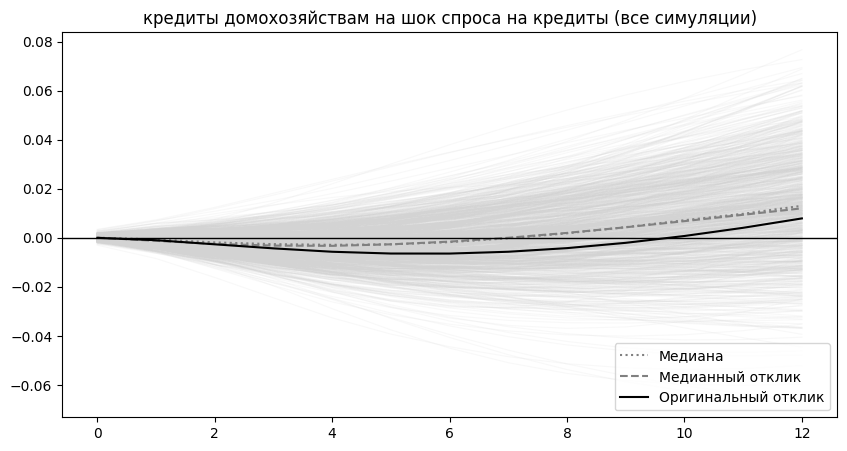

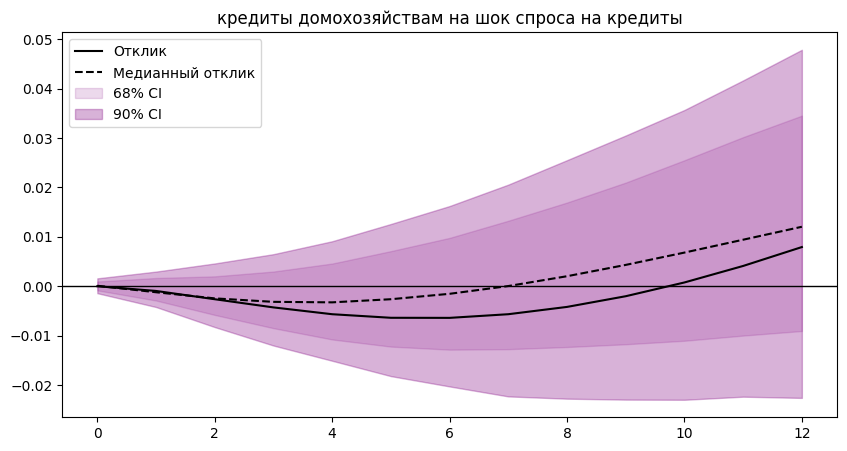

In [8]:
model.plot_single_irf(irf_sims,
                list(model.y_dict.keys())[5],
                'шок спроса на кредиты',
                'purple',
                plot_simulations = True,
                horizon=20,
                cumm = True)

In [13]:
U = np.linalg.inv(model.B0inv) @ model.E
nobs = model.T - model.p
1/nobs*pd.DataFrame(U@U.T)

,0,1,2,3,4,5
0,1.000000e+00,6.925565e-18,3.601464e-17,-3.057603e-16,3.882231e-17,-3.316804e-17
1,6.925565e-18,1.000000e+00,-2.449495e-16,2.050681e-16,-6.328597e-17,1.154145e-16
2,3.601464e-17,-2.449495e-16,1.000000e+00,2.941664e-16,2.687383e-16,-8.067662e-18
3,-3.057603e-16,2.050681e-16,2.941664e-16,1.000000e+00,-2.293954e-17,-3.660648e-17
4,3.882231e-17,-6.328597e-17,2.687383e-16,-2.293954e-17,1.000000e+00,-1.889608e-16
5,-3.316804e-17,1.154145e-16,-8.067662e-18,-3.660648e-17,-1.889608e-16,1.000000e+00


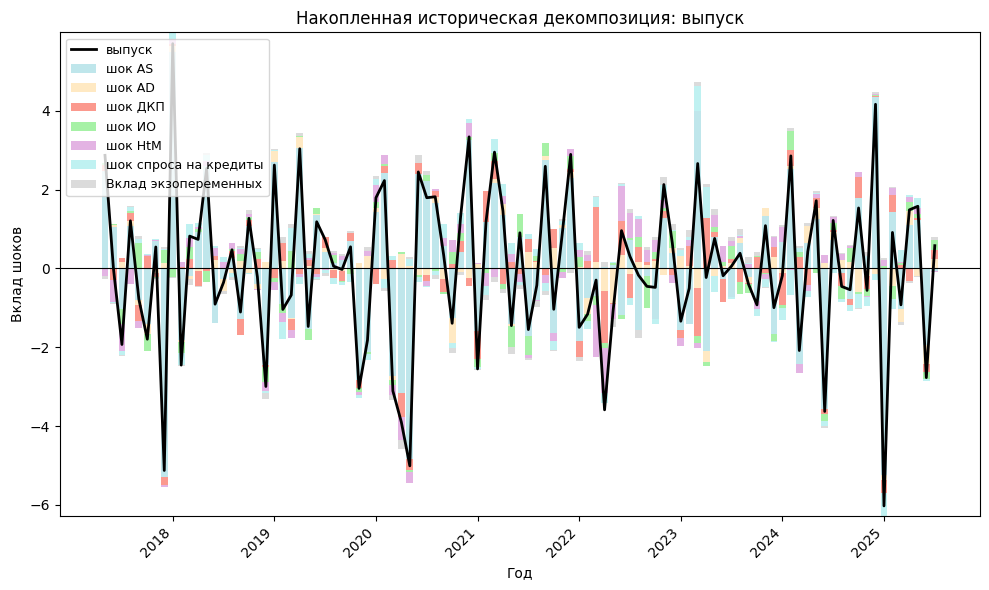

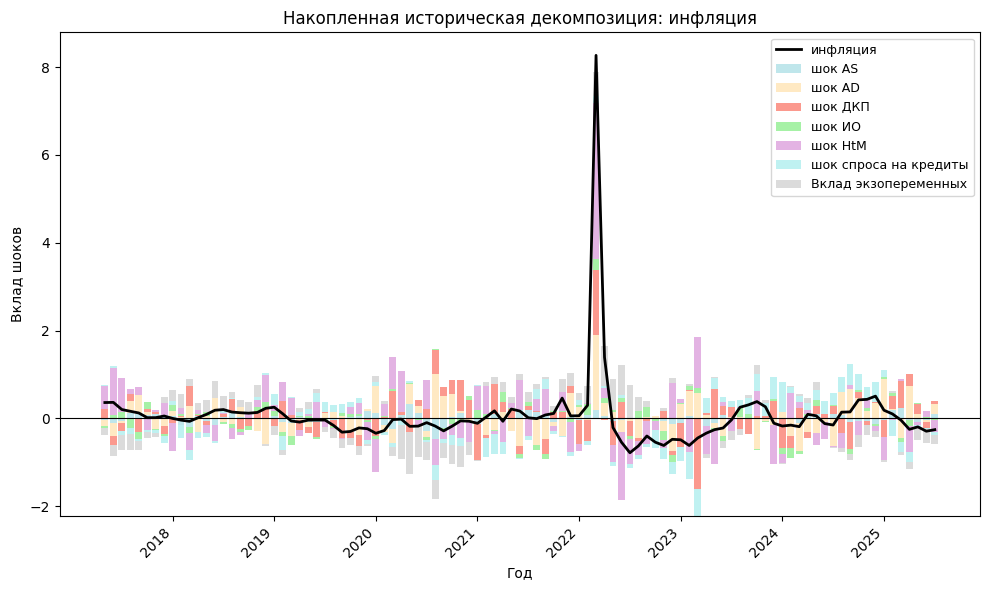

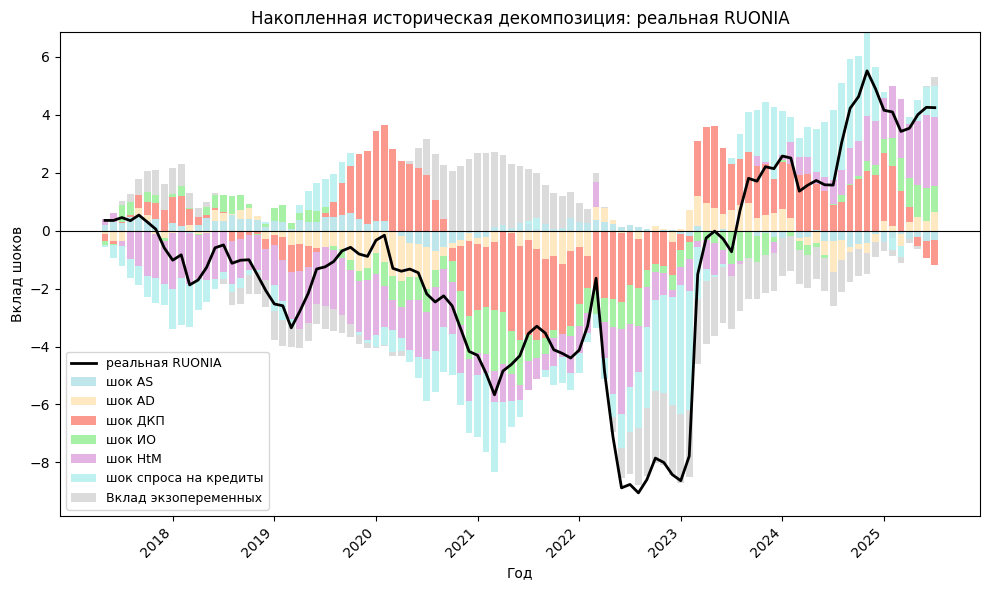

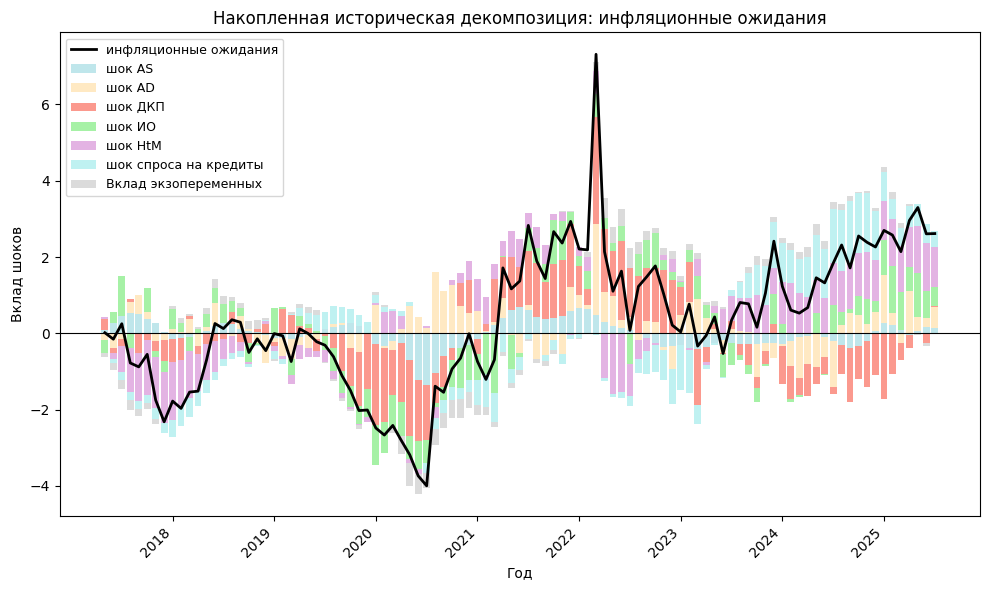

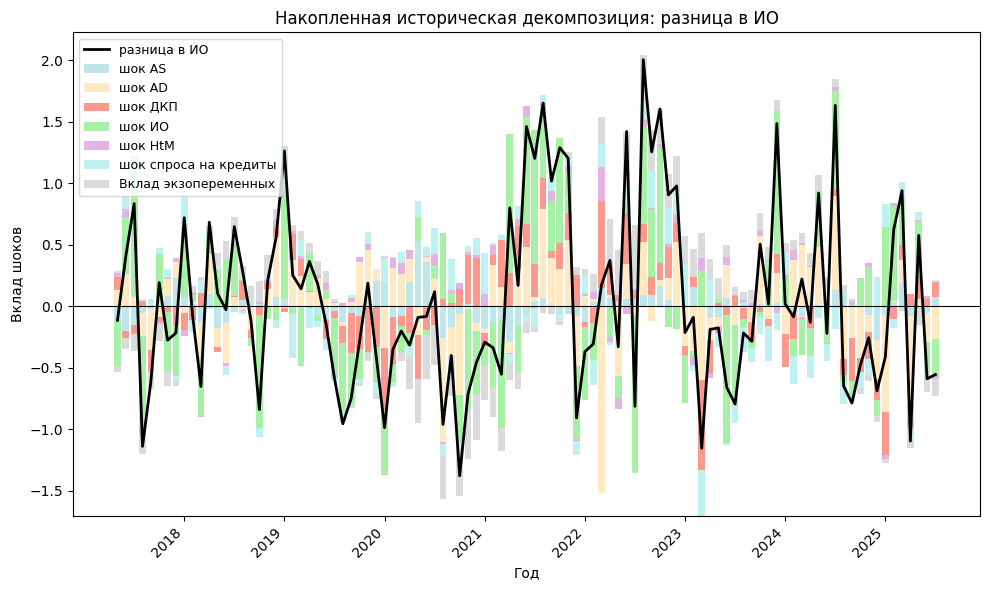

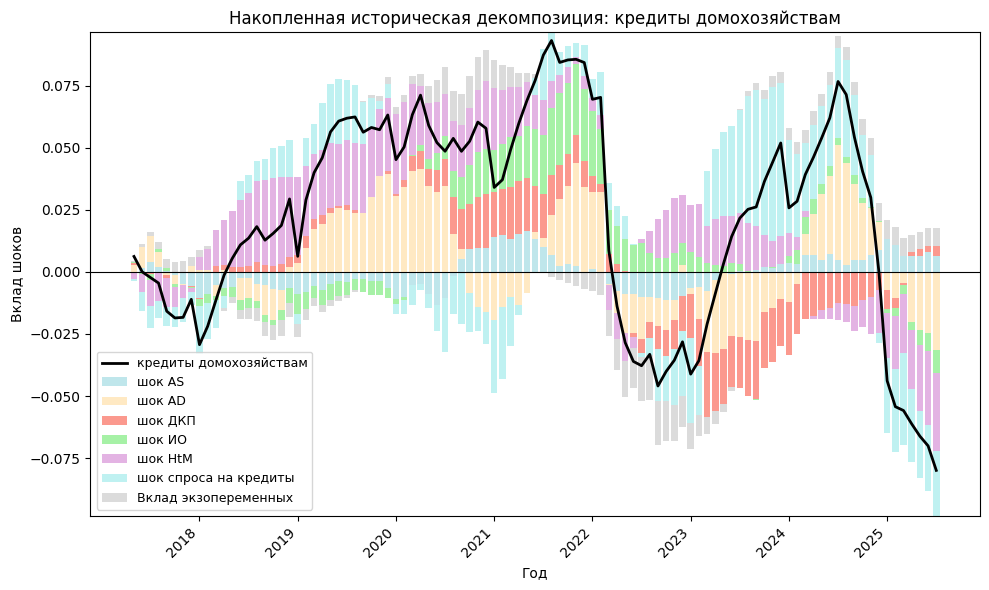

In [11]:
hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


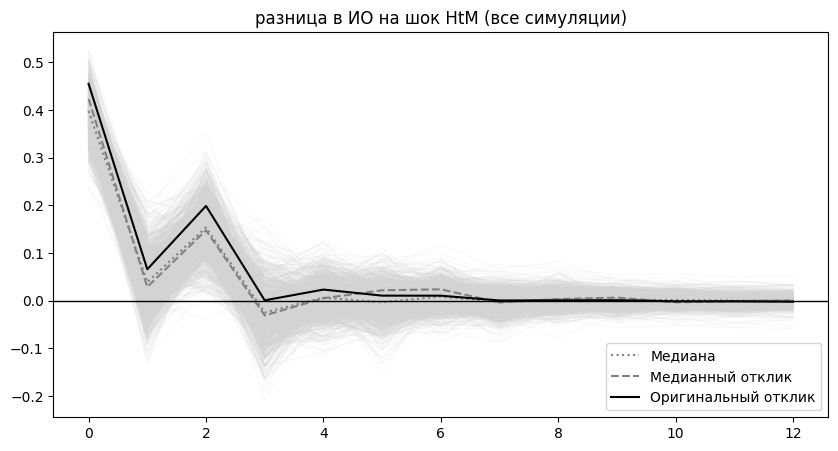

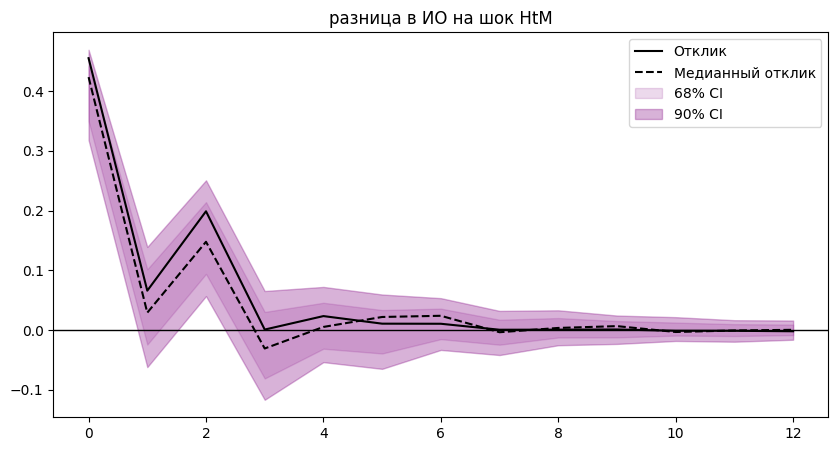

In [6]:
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъясненно шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]
share_hd_full.astype(float).round(3)*100

model.plot_single_irf(irf_sims,
                'pi_e_hete',
                'шок HtM',
                'purple',
                plot_simulations = True,
                horizon=20,
                cumm = False)

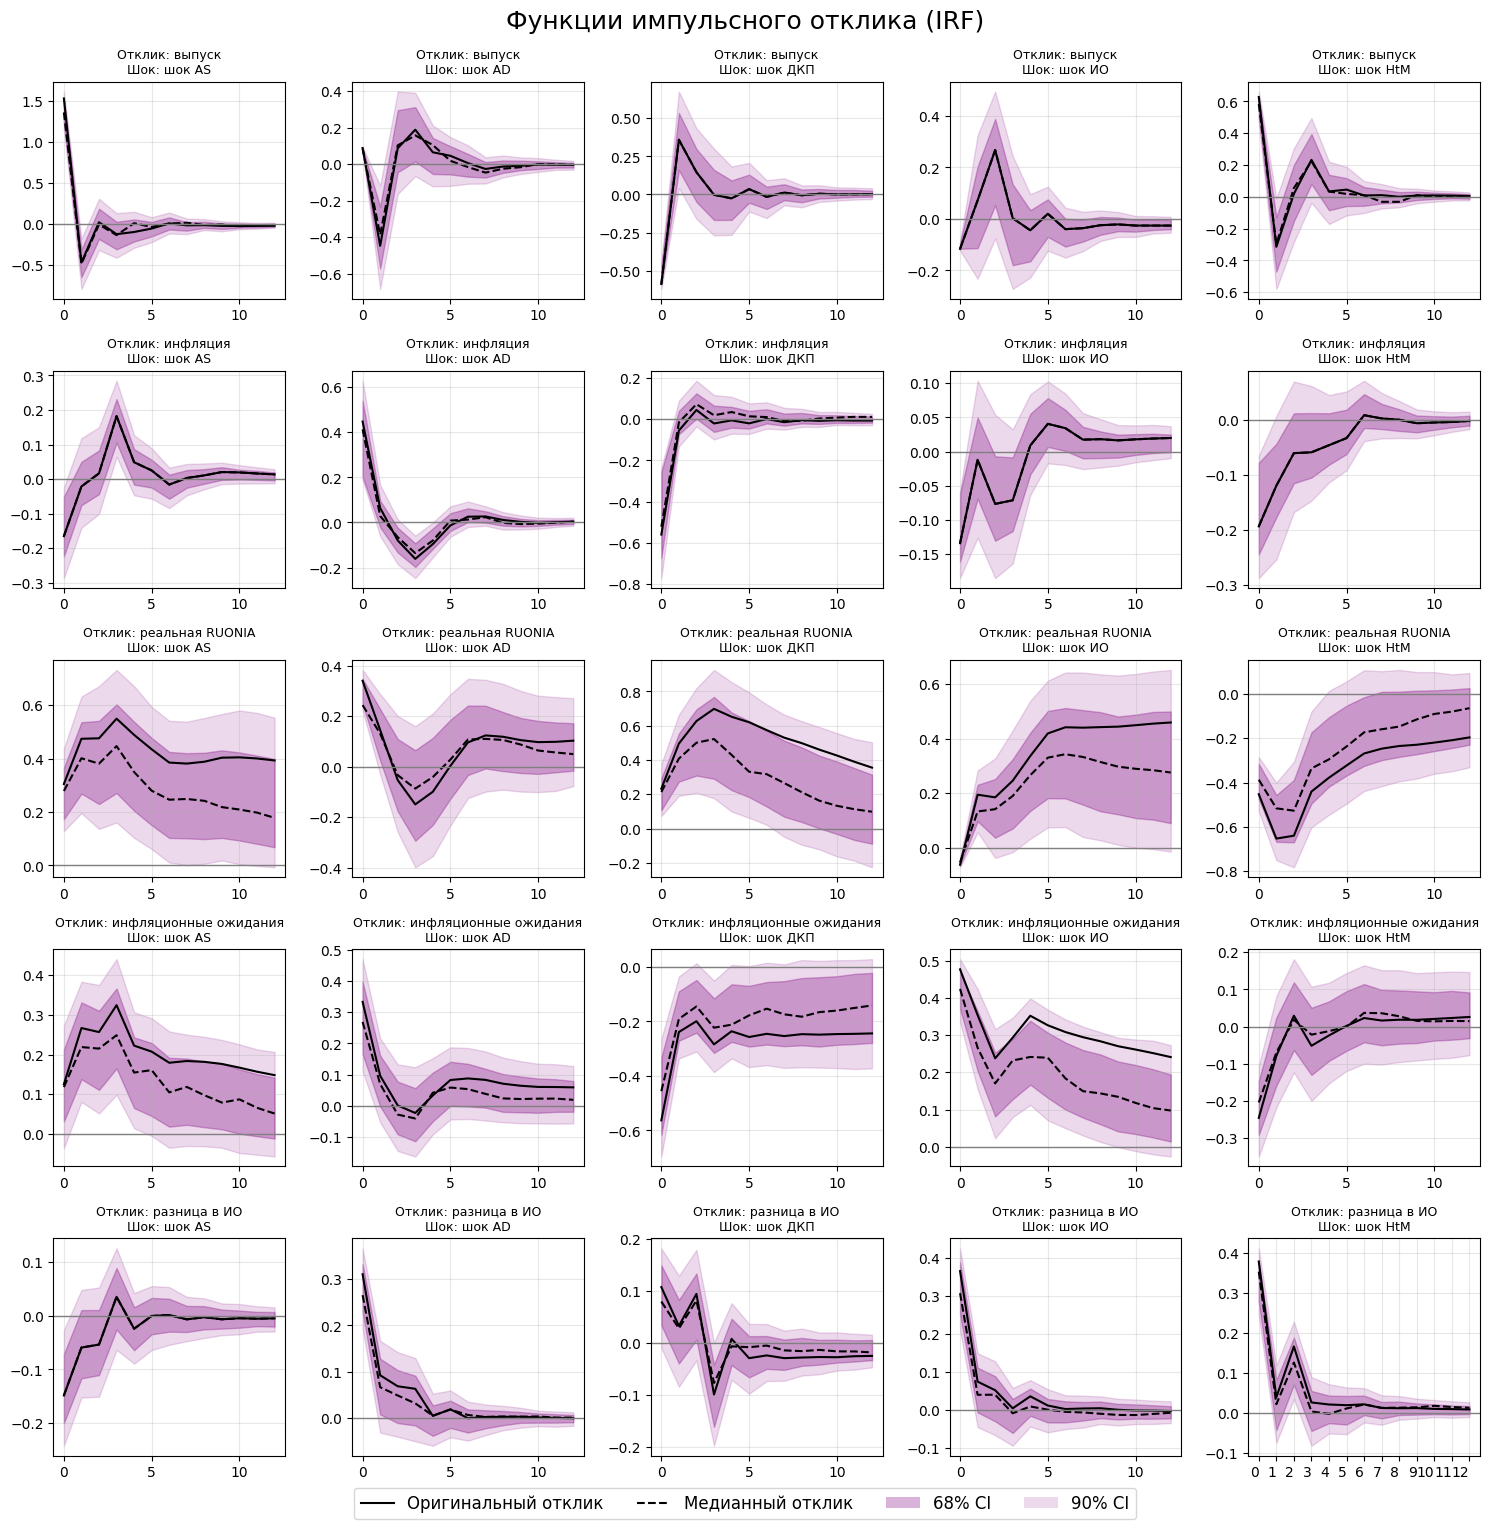

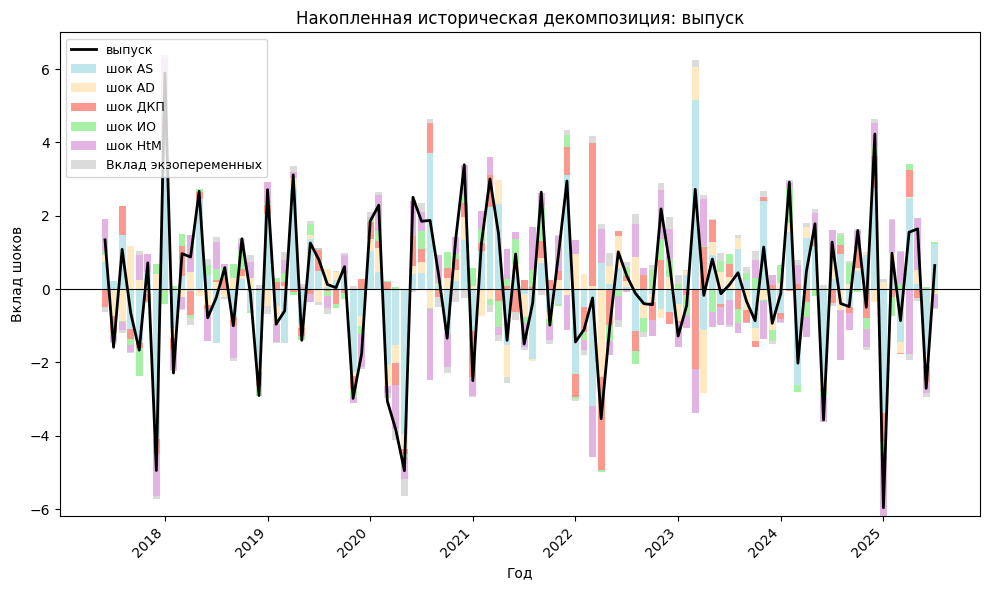

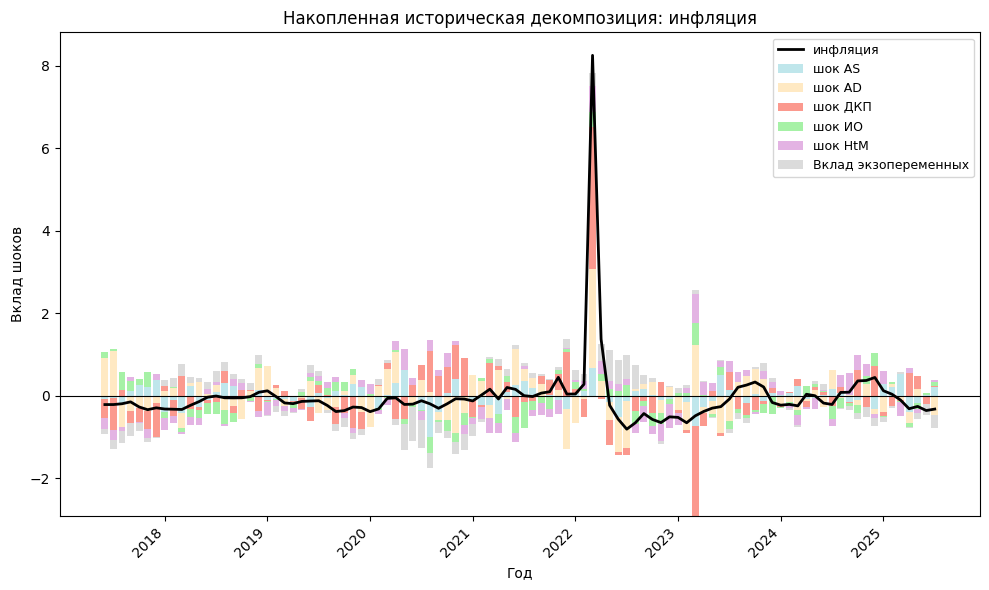

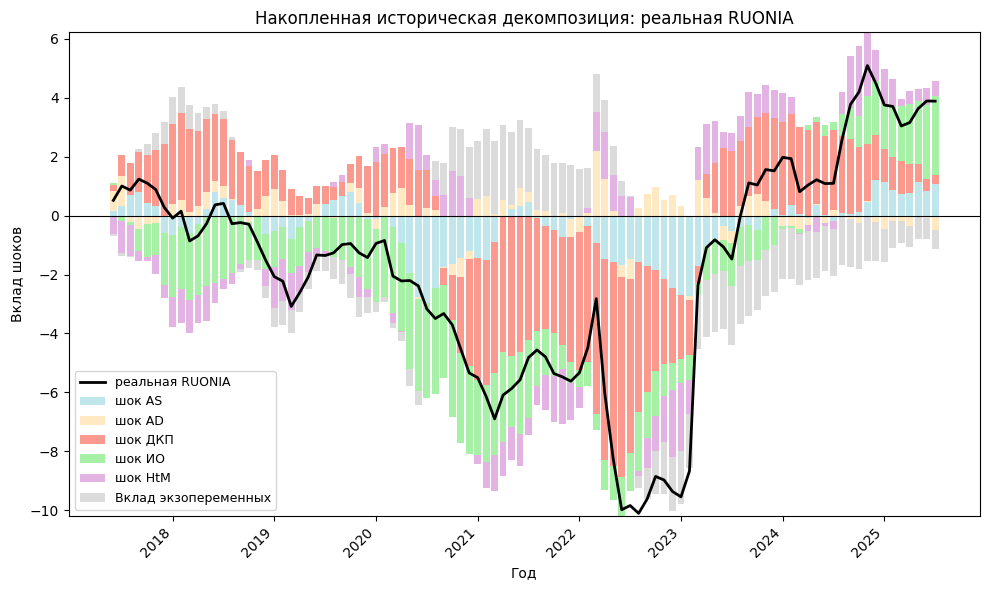

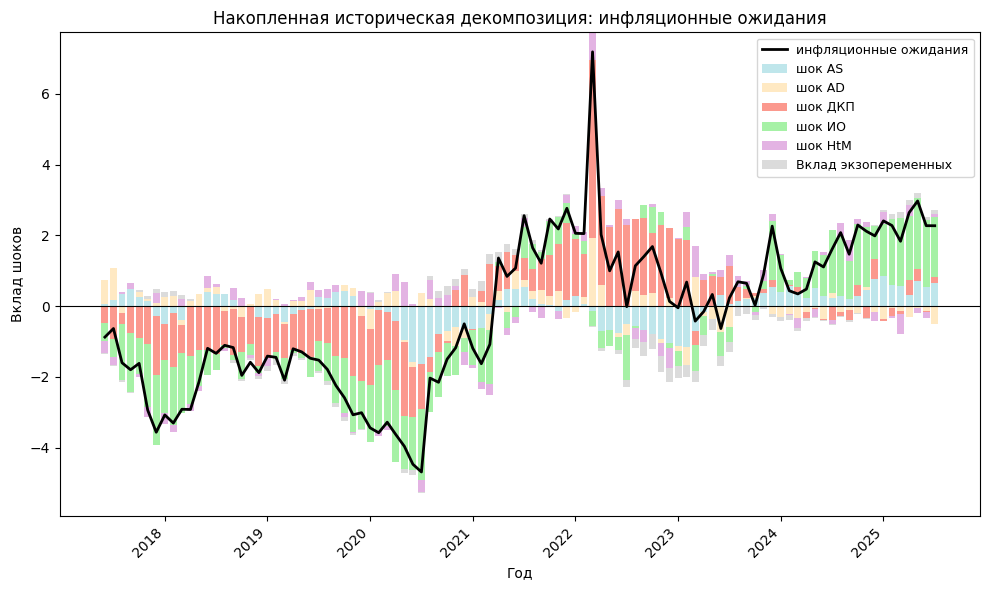

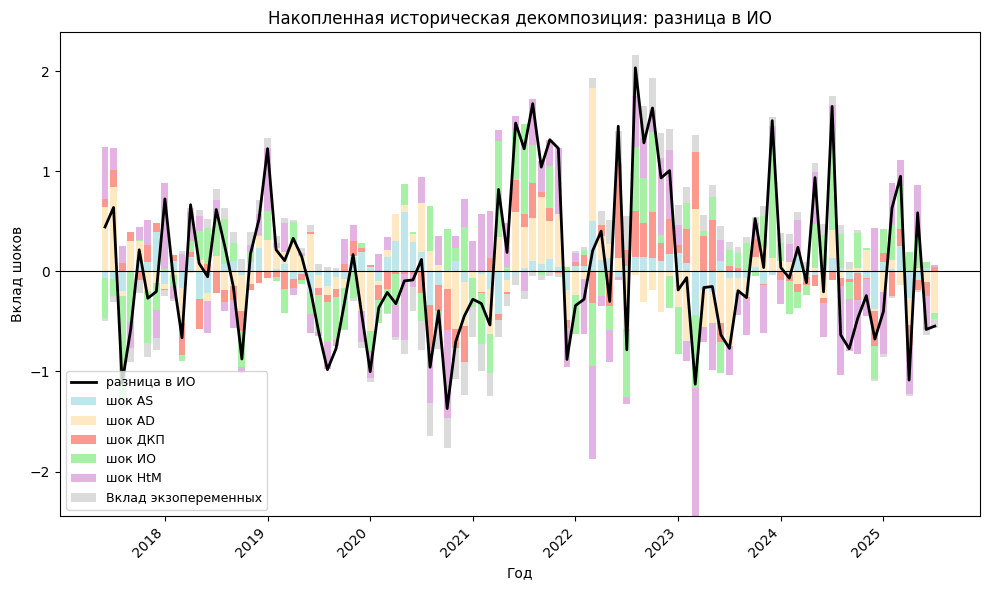

,выпуск,инфляция,реальная RUONIA,инфляционные ожидания,разница в ИО
шок AS,38.1,11.9,10.5,13.8,9.5
шок AD,11.8,23.3,5.0,8.6,18.9
шок ДКП,13.8,21.5,32.4,33.2,11.8
шок ИО,7.9,9.8,21.4,30.3,22.7
шок HtM,19.2,12.3,11.4,7.4,24.4
Вклад экзопеременных,3.9,11.1,15.1,4.1,8.7
Необъясненно шоками,5.3,10.3,4.3,2.6,4.0


In [7]:
short_run_anchor = [
    (0, 0, 1, 0, 1),
]
long_run_anchor = [
    (0, 2, 2, 10)
]
short_run_signs = [(0, 1, 2, False, 0, 2),
                   (0, 1, 1, True, 0, 1),
                   (0, 2, 2, True, 0, 1),
                   (0, 3, 3, True, 0, 1),
                   (0, 0, 0, True, 0, 1),
                   (0, 3, 2, False, 0, 1),
                   (0, 4, 3, True, 0, 1),
                   (0, 1, 4, False, 0, 1),
                   (0, 4, 2, True, 0, 1),
                   ]
long_run_signs = [
    (0, 2, 1, True,  3),
    (0, 3, 2, False, 3),
]

#data = pd.read_pickle('data.pkl')
lag = 3

endog_names = ['ipi', 'ru_cpi', 'real_ruonia', 'pi_e', 'pi_e_hete']
exog_names  = ['real_brent']

df_endog = data.loc[endog_names, :]   # K×T
df_exog  = data.loc[exog_names, :]    # K_ex×T

model = SVAR_KL(
    data=df_endog,
    p=lag,
    exog=df_exog,              #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок AS', 'шок AD', 'шок ДКП', 'шок ИО', 'шок HtM'],
    y_dict = ['выпуск', 'инфляция', 'реальная RUONIA', 
              'инфляционные ожидания', 'разница в ИО']
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 12
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=12,
                     main_color='purple')
hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъясненно шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]
share_hd_full.astype(float).round(3)*100

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


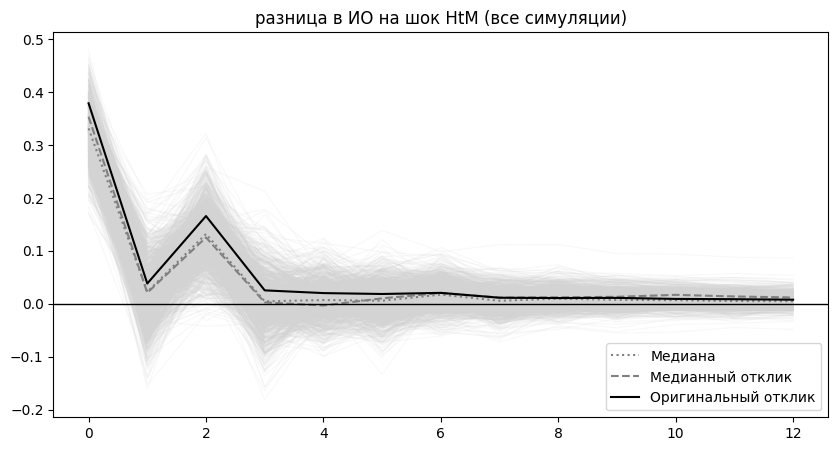

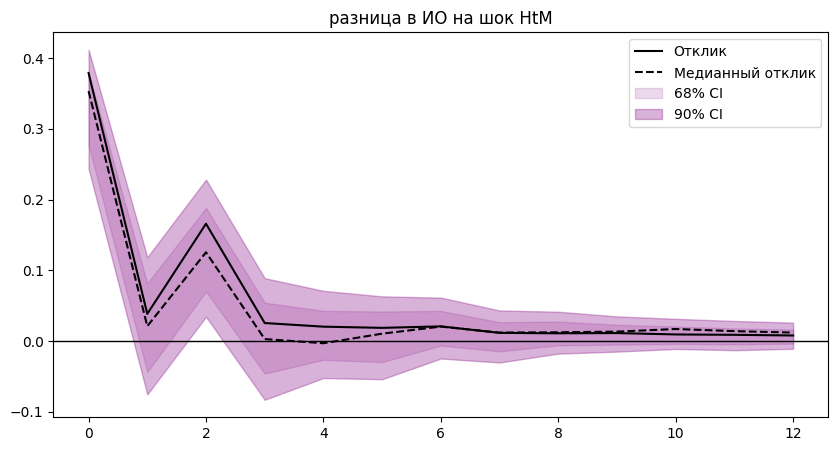

In [8]:
model.plot_single_irf(irf_sims,
                'pi_e_hete',
                'шок HtM',
                'purple',
                plot_simulations = True,
                horizon=20,
                cumm = False)